In [ ]:
!pip install uv
!uv pip install qiskit qiskit-aer pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 60.4 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 1.63s
Prepared 5 packages in 893ms
Installed 5 packages in 25ms
 + pylatexenc==2.10
 + qiskit==2.4.1
 + qiskit-aer==0.17.2
 + rustworkx==0.17.1
 + stevedore==5.7.0


In [ ]:
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit.circuit.library import RealAmplitudes
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
def get_result(qc):
    simulator = AerSimulator()
    compiled = transpile(qc, simulator)
    return simulator.run(compiled,shots=100).result().get_counts()


## Deutsch-Jozsa Problem
### Definition
Consider a function $f$ that takes $n$ binary values as input ($0$ or $1$) and returns $0$ or $1$ as output.

We do not know this function, but we know that it satisfies one of the following two properties :
- $f$ is **constant**, i.e. it always produces the same output, regardless of the input.
- $f$ is **balanced**, i.e. it produces different outputs for exactly half of the inputs.

The aim is to **determine whether $f$ is constant or balanced**.

In classical computing, you need to evaluate $f$ up to $2^{n-1}+1$ times.  
In quantum computing, the Deutsch-Jozsa algorithm allows this to be done in **a single** instruction.


| Case                     | Definition                                      |  Example of $f(x)$   | Used Quantum circuit      | Result |
|------------------------|--------------------------------------------------|--------------------|----------------------|------------------|
| **Constant**          | $f(x_0, ..., x_{n-1}) = c$ for all $x$           | $f(x) = 0$         | Nothing     | $0$              |
| **Balanced**         | $f$ outputs $0$ and $1$ equally often            | $f(x_0,...,x_{n-1}) = x_0 \oplus ... \oplus x_{n-1}$ | CNOT gates | $1$              |


---

### Creating a balanced function

1. Creating a Quantum circuit with $n$ qubits (n input qubits and 1 ancilla). Let's call it "balanced_function" :  
2. Apply a CNOT gate: $CNOT(q_i, q_{n})$ for each input qubit $i$
3. Transform the circuit into a gate
4. Rename it like this :  **$f(x)$**


In [ ]:
def create_balanced_function(n=2)->QuantumCircuit:

    ########Votre code ici
    balanced_function = QuantumCircuit(n, 0)
    for i in range(n - 1):
        balanced_function.cx(i, n - 1)
    ##############################
    balanced_function = balanced_function.to_gate()
    balanced_function.name = "f(x)"
    return balanced_function


#### Creating a constant function

1. Create a circuit with $n$ qubits (n input qubits and 1 ancilla):  
2. Transform the circuit into a gate
3. Rename it like this :  **$f(x)$**


In [ ]:
def create_constant_function(n=2)->QuantumCircuit:

    ########Votre code ici
    constant_function = QuantumCircuit(n,0)
    ##############################
    constant_function = constant_function.to_gate()
    constant_function.name = "f(x)"
    return constant_function


### Deutsch-Jozsa Algorithm
In this part, you need to create inside the function the circuit $qc$:

1. Create a circuit qc with $n$ qubits and $n-1$ classical bits
2. Transform $q_n$(ancilla) into $|1>$ by applying a **Pauli-X** gate
3. Apply a **Hadamard** gate on all qubits
4. Add the oracle in the circuit
5. Add a **Hadamard** gate on the input qubits ($q_0$ to $q_{n-1}$)
6. Measure the input qubits


In [ ]:
def deutsch_algorithm(oracle, n=2):
    n_input = n - 1  # qubits d'entrée
    qc = QuantumCircuit(n, n_input)
    qc.x(n - 1)
    qc.barrier()
    qc.h(range(n))
    qc.append(oracle, list(range(n)))
    qc.h(range(n_input))
    qc.measure(range(n_input), range(n_input))
    return qc

équilibré : {'1111': 100}
non équilibré : {'0000': 100}


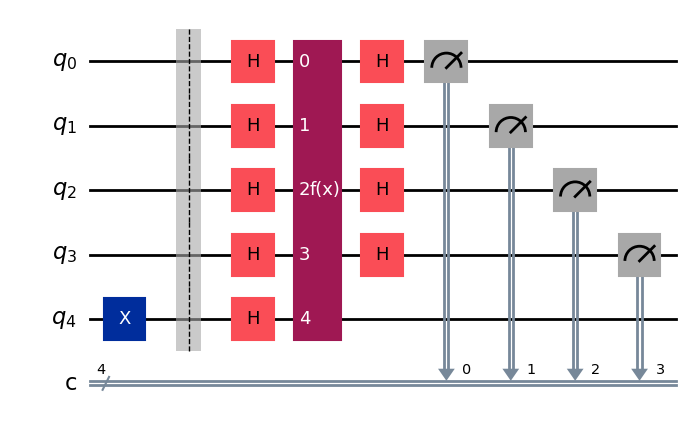

In [ ]:
n=5
balanced_function= create_balanced_function(n)
constant_function= create_constant_function(n)
print(f"équilibré : {get_result(deutsch_algorithm(balanced_function,n))}")
print(f"non équilibré : {get_result(deutsch_algorithm(constant_function,n))}")
deutsch_algorithm(balanced_function,n).draw("mpl")